# Local Search

CSI 4106 Introduction to Artificial Intelligence

Marcel Turcotte  
Version: Jan 30, 2026 12:30

# Preamble

## Message of the Day

![](https://media.nature.com/w1248/magazine-assets/d41586-025-03340-w/d41586-025-03340-w_51595896.jpg?as=webp)

[Universities are embracing AI: will students get smarter or stop
thinking?](https://www.nature.com/articles/d41586-025-03340-w), Nature
News, 2025-10-21.

## Learning Objectives

- **Understand** the concept and application of local search algorithms
  in optimization problems.
- **Implement** and analyze the hill-climbing algorithm, recognizing its
  limitations such as local maxima and plateaus.
- **Apply** effective state representation strategies in problems like
  the 8-Queens to enhance search efficiency.
- **Explain** how simulated annealing overcomes local optima by allowing
  probabilistic acceptance of worse states.
- **Analyze** the influence of temperature and energy difference on the
  acceptance probability in simulated annealing.
- **Recognize** the application of simulated annealing in solving
  complex optimization problems like the Travelling Salesman Problem
  (TSP).

In this presentation, we will analyze two local search algorithms: hill
climbing and simulated annealing. Our goal is to explain the concept of
local search and examine methods for avoiding local optima. We will
briefly discuss hill climbing, given its simplicity, and spend more time
on simulated annealing, a very useful algorithm.

# Introduction

## Context

- Focus has been on **finding paths** in **state space**.

- Some problems prioritize the **goal state** over the **path**.

  - Integrated-circuit design
  - Job shop scheduling
  - Automatic programming

The importance of the path versus the goal state hinges on the problem’s
nature. For instance, in a routing problem, the path is the critical
piece of information sought.

## 8-Queens Problem

In [1]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import numpy as np

def display_n_queens(board, width):
    n = len(board)

    # Create a checkerboard pattern
    board_matrix = np.zeros((n, n))
    for row in range(n):
        for col in range(n):
            if (row + col) % 2 == 0:
                board_matrix[row, col] = 1  # White tiles
            else:
                board_matrix[row, col] = 0.5

    # Create custom colormap: gray for 0.5 and white for 1
    cmap = ListedColormap(['lightgray', 'white'])

    # Create the plot
    fig, ax = plt.subplots(figsize=(width, width))
    ax.imshow(board_matrix, cmap=cmap, extent=(0, n, 0, n))

    # Add the queen markers
    for col in range(n):
        row = board[col]
        ax.text(col + 0.5, n - row - 0.5, '♛', fontsize=32, ha='center', va='center', color='black')

    # Add grid lines
    ax.set_xticks(np.arange(n+1), minor=True)
    ax.set_yticks(np.arange(n+1), minor=True)
    ax.grid(which='minor', color='black', linestyle='-', linewidth=2)

    # Remove axis labels and ticks
    ax.set_xticks([])
    ax.set_yticks([])
    ax.tick_params(axis='both', which='both', length=0)  # Ensure ticks are completely disabled

    plt.title(f"{n}-Queens Problem")
    plt.show()

## 8-Queens Problem

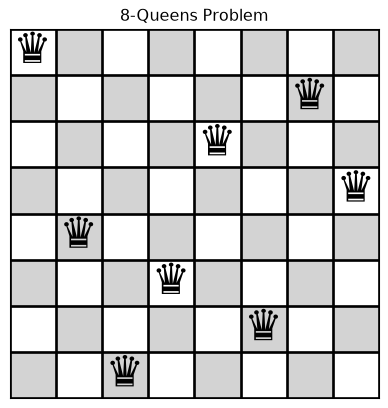

In [2]:
# Example board for the 8-queens problem
# Represents one valid solution
board = [0, 4, 7, 5, 2, 6, 1, 3]  

display_n_queens(board, 5)

The **[8-Queens
problem](https://en.wikipedia.org/wiki/Eight_queens_puzzle)** involves
placing eight queens on an $8 \times 8$ chessboard such that **no two
queens threaten each other**, meaning no two queens share the same row,
column, or diagonal.

For an $8 \times 8$ chessboard, there exist precisely 92 distinct
solutions. Eliminating symmetry, one finds 12 fondamental solutions. In
the more general scenario of an $n \times n$ chessboard, the exact
number of solutions has been determined for all $n$ values up to and
including 27.

## Definition

>  **(Russell and Norvig 2020, 110)**
>
> **Local search algorithms** operate by searching from a **start
> state** to **neighboring states**, without keeping track of the paths,
> nor the set of states that have been reached.

Optimizes **memory utilization** while effectively solving problems in
**extensive** or **infinite state spaces**.

This algorithm lacks a systematic approach and does not ensure the
discovery of an optimal solution.

## Problem Definition

Find the “best” state according to an **objective function**, thereby
locating the **global maximum**.

This **optimization problem** is commonly referred to as **hill
climbing**.

# Hill-Climbing

## Hill-Climbing

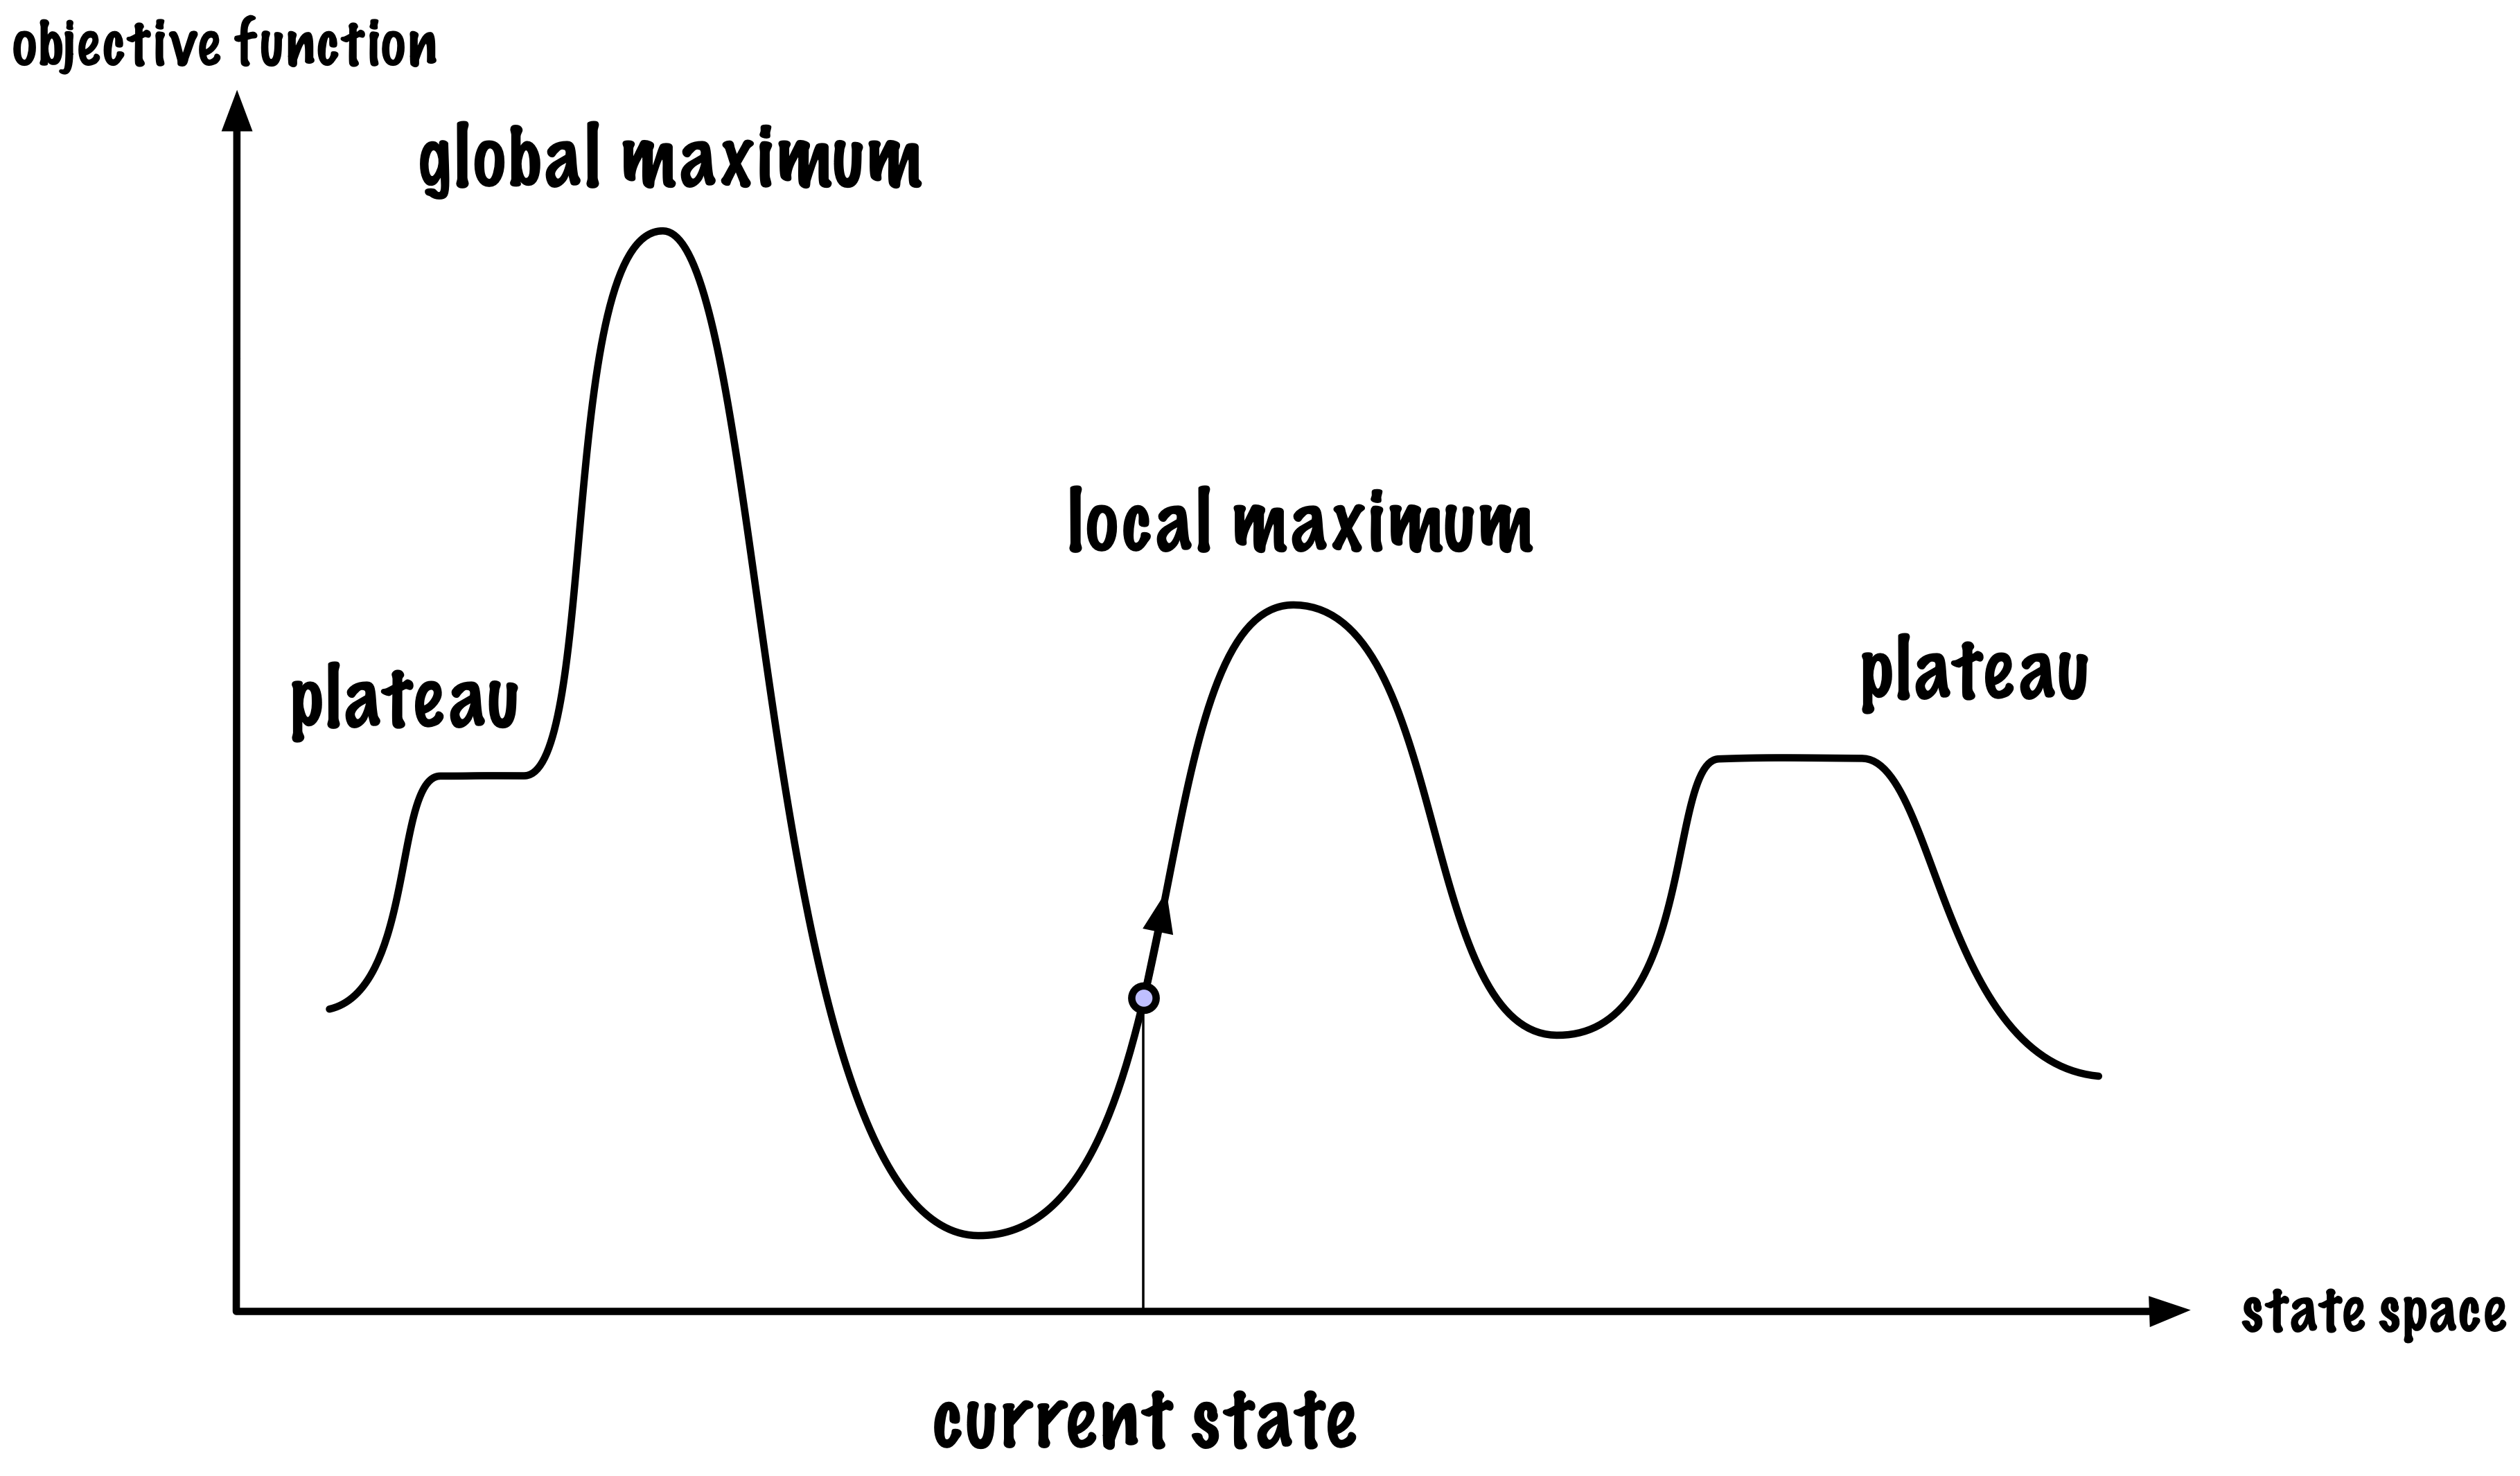

## Hill-Climbing

Given as in input a *problem*

- *current* is the *initial state* of *problem*

- **while** *not done* **do**

  - *nighbour* is the highest-valued successor state of *current*
  - if value(*neighbour*) $\le$ value(*current*) the **return**
    *current*
  - set *current* to *neighbour*

Hill climbing neither records previously visited states nor anticipates
beyond its immediate neighbors. It keeps track of one current state
moves in the direction of the **steepest ascent**.

Notably, by inverting the sign of the objective function, the algorithm
can be adapted to seek a local minimum instead.

## 8-Queens

How would you represent the **current state**?

. . .

Why is using a grid to represent the **current state** suboptimal?

. . .

A grid representation **permits the illegal placement** of two queens in
the same column.

. . .

Instead, we can represent the state as a list ($\mathrm{state}$), where
each element corresponds to the row position of the queen in its
respective column.

In other words, $\mathrm{state}[i]$ is the row of the queen is column
$i$.

## State Representation

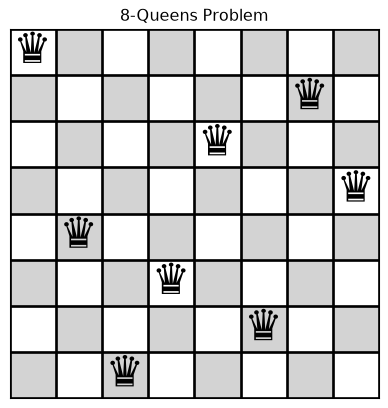

In [3]:
# Example board for the 8-queens problem
board = [0, 4, 7, 5, 2, 6, 1, 3]  # Represents one valid solution for 8-queens

display_n_queens(board, 5)

``` python
state = [0, 4, 7, 5, 2, 6, 1, 3]
```

## `create_initial_state`

In [5]:
import random
random.seed(7)

def create_initial_state(n):

    """Generates a random initial state with one queen per column."""

    return [random.randint(0, n - 1) for _ in range(n)]

**What** do you think?

## `create_initial_state`

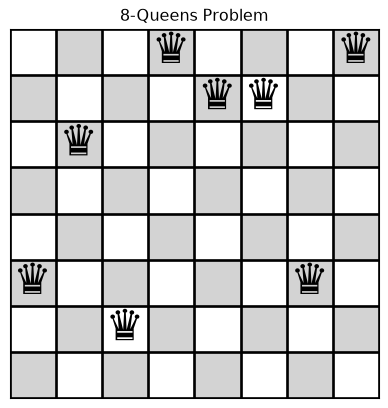

In [6]:
state = create_initial_state(8)
display_n_queens(state, 5)

In [7]:
state 

[5, 2, 6, 0, 1, 1, 5, 0]

Permits two queens in the **same row**? **How** can this be resolved?

## Representation of 8-Queens

$8 \times 8$ chessboard.

- **Unconstrained Placement**: $\binom{64}{8} = 4,426,165,368$ possible
  configurations, representing the selection of 8 squares from 64.

- **Column Constraint**: Use a list of length 8, with each entry
  indicating the row of a queen in its respective column, resulting in
  $8^8 = 16,777,216$ configurations.

- **Row and Column Constraints**: Model board states as permutations of
  the 8 row indices, reducing configurations to $8! = 40,320$.

This underscores the significance of selecting a good representation.

## `create_initial_state`

In [8]:
import random
random.seed(7)

def create_initial_state(n):

    """Generates a permutation of numbers from 0 to n-1 as the initial state."""

    state = list(range(n))
    random.shuffle(state)

    return state

## `create_initial_state`

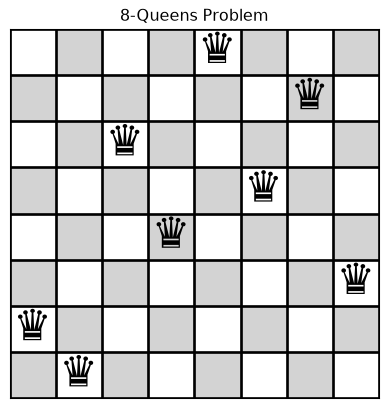

In [9]:
state = create_initial_state(8)
display_n_queens(state, 5)

In [10]:
state 

[6, 7, 2, 4, 0, 3, 1, 5]

## `calculate_conflicts`

In [11]:
def calculate_conflicts(state):

    n = len(state)
    conflicts = 0

    for col_i in range(n):
        for col_j in range(col_i + 1, n):
            row_i = state[col_i]
            row_j = state[col_j]
            if row_i == row_j:                 # same row
                conflicts += 1
            if col_i - row_i == col_j - row_j: # same diagonal
                conflicts += 1
            if col_i + row_i == col_j + row_j: # same anti-diagonal
                conflicts += 1

    return conflicts

## `calculate_conflicts`

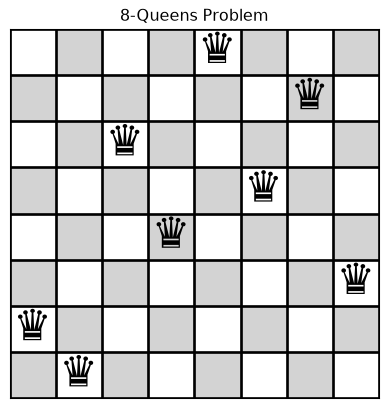

In [12]:
display_n_queens(state, 5)

    5

## `get_neighbors_rn`

In [14]:
def get_neighbors_rn(state):

    """Generates neighboring states by moving on queen at a time to a new row."""

    neighbors = []
    n = len(state)

    for col in range(n):
        for row in range(n):
            if (state[col] != row):
              new_state = state[:] # create a copy of the state
              new_state[col] = row
              neighbors.append(new_state)

    return neighbors

Russell and Norvig (2020), $8 \times 7 = 56$ neighbours

## `get_neighbors_rn`

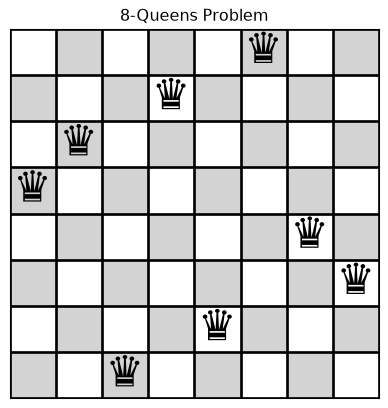

In [15]:
etat = create_initial_state(8)
display_n_queens(etat, 5)

## `get_neighbors_rn`

In [16]:
initial_state_8 = create_initial_state(8)
print(initial_state_8)
for s in get_neighbors_rn(initial_state_8):
  print(f"{s} -> # of conflicts = {calculate_conflicts(s)}")

[7, 4, 2, 5, 1, 0, 3, 6]
[0, 4, 2, 5, 1, 0, 3, 6] -> # of conflicts = 6
[1, 4, 2, 5, 1, 0, 3, 6] -> # of conflicts = 5
[2, 4, 2, 5, 1, 0, 3, 6] -> # of conflicts = 6
[3, 4, 2, 5, 1, 0, 3, 6] -> # of conflicts = 6
[4, 4, 2, 5, 1, 0, 3, 6] -> # of conflicts = 6
[5, 4, 2, 5, 1, 0, 3, 6] -> # of conflicts = 8
[6, 4, 2, 5, 1, 0, 3, 6] -> # of conflicts = 5
[7, 0, 2, 5, 1, 0, 3, 6] -> # of conflicts = 4
[7, 1, 2, 5, 1, 0, 3, 6] -> # of conflicts = 4
[7, 2, 2, 5, 1, 0, 3, 6] -> # of conflicts = 3
[7, 3, 2, 5, 1, 0, 3, 6] -> # of conflicts = 5
[7, 5, 2, 5, 1, 0, 3, 6] -> # of conflicts = 3
[7, 6, 2, 5, 1, 0, 3, 6] -> # of conflicts = 4
[7, 7, 2, 5, 1, 0, 3, 6] -> # of conflicts = 4
[7, 4, 0, 5, 1, 0, 3, 6] -> # of conflicts = 5
[7, 4, 1, 5, 1, 0, 3, 6] -> # of conflicts = 6
[7, 4, 3, 5, 1, 0, 3, 6] -> # of conflicts = 8
[7, 4, 4, 5, 1, 0, 3, 6] -> # of conflicts = 6
[7, 4, 5, 5, 1, 0, 3, 6] -> # of conflicts = 7
[7, 4, 6, 5, 1, 0, 3, 6] -> # of conflicts = 6
[7, 4, 7, 5, 1, 0, 3, 6] -> # of co

## `get_neighbors`

In [17]:
def get_neighbors(state):

    """Generates neighboring states by swapping two rows."""

    neighbors = []
    n = len(state)

    for i in range(n):
        for j in range(i + 1, n):
            new_state = state[:]
            new_state[i], new_state[j] = new_state[j], new_state[i]
            neighbors.append(new_state)

    return neighbors

$\frac{8 \times 7}{2} = 28$ neighbours

## `get_neighbors`

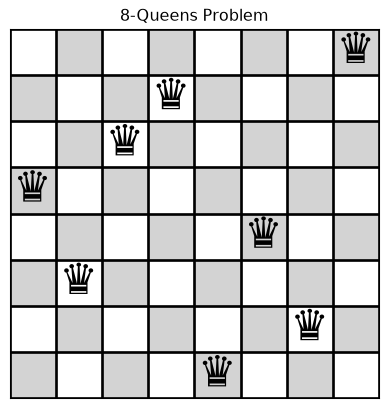

In [18]:
etat = create_initial_state(8)
display_n_queens(etat, 5)

## `get_neighbors`

In [19]:
print(initial_state_8)
for s in get_neighbors(initial_state_8):
  print(f"{s} -> # of conflicts = {calculate_conflicts(s)}")

[7, 4, 2, 5, 1, 0, 3, 6]
[4, 7, 2, 5, 1, 0, 3, 6] -> # of conflicts = 4
[2, 4, 7, 5, 1, 0, 3, 6] -> # of conflicts = 6
[5, 4, 2, 7, 1, 0, 3, 6] -> # of conflicts = 7
[1, 4, 2, 5, 7, 0, 3, 6] -> # of conflicts = 2
[0, 4, 2, 5, 1, 7, 3, 6] -> # of conflicts = 4
[3, 4, 2, 5, 1, 0, 7, 6] -> # of conflicts = 5
[6, 4, 2, 5, 1, 0, 3, 7] -> # of conflicts = 5
[7, 2, 4, 5, 1, 0, 3, 6] -> # of conflicts = 3
[7, 5, 2, 4, 1, 0, 3, 6] -> # of conflicts = 3
[7, 1, 2, 5, 4, 0, 3, 6] -> # of conflicts = 4
[7, 0, 2, 5, 1, 4, 3, 6] -> # of conflicts = 5
[7, 3, 2, 5, 1, 0, 4, 6] -> # of conflicts = 3
[7, 6, 2, 5, 1, 0, 3, 4] -> # of conflicts = 5
[7, 4, 5, 2, 1, 0, 3, 6] -> # of conflicts = 10
[7, 4, 1, 5, 2, 0, 3, 6] -> # of conflicts = 2
[7, 4, 0, 5, 1, 2, 3, 6] -> # of conflicts = 5
[7, 4, 3, 5, 1, 0, 2, 6] -> # of conflicts = 7
[7, 4, 6, 5, 1, 0, 3, 2] -> # of conflicts = 7
[7, 4, 2, 1, 5, 0, 3, 6] -> # of conflicts = 3
[7, 4, 2, 0, 1, 5, 3, 6] -> # of conflicts = 5
[7, 4, 2, 3, 1, 0, 5, 6] -> # of c

## `hill_climbing`

In [20]:
def hill_climbing(current_state):

    current_conflicts = calculate_conflicts(current_state)

    while True:

        if current_conflicts == 0:
          return curent_state

        neighbors = get_neighbors(current_state)

        conflicts = [calculate_conflicts(neighbor) for neighbor in neighbors]

        if (min(conflicts)) > current_conflicts:
          return None # No improvement found, stuck at local minimum

        arg_best = np.argmin(conflicts)
        curent_state = neighbors[arg_best]
        current_conflicts = conflicts[arg_best]

The program above presents a major issue. What exactly is it?

It is important to note that, in this particular context, the problem is
defined such that the sought solution is free of any conflict. However,
in some optimization problems, the minimum value of the objective
function is not predetermined.

The main issue is that the algorithm might enter an infinite loop if the
condition `min(conflicts == current_conflicts)` is satisfied.

Two scenarios may arise: either the plateau is followed by an ascending
slope, or it represents a local maximum. In the first case, the
algorithm could potentially exit the plateau, although this is not
guaranteed. To prevent infinite loops, it would be wise to implement an
appropriate mechanism.

## `hill_climbing` (take 2)

In [21]:
MAX_SIDE_MOVES = 100

def hill_climbing(current_state):

    conflicts_current_state = calculate_conflicts(current_state)
    side_moves = 0

    while True:

        if conflicts_current_state == 0:
          return current_state

        neighbors = get_neighbors(current_state)

        conflicts = [calculate_conflicts(voisin) for voisin in neighbors]

        if (min(conflicts)) > conflicts_current_state:
          return None  # No improvement, local maxima

        if (min(conflicts)) == conflicts_current_state:
          side_moves += 1  # Plateau

        if side_moves > MAX_SIDE_MOVES:
          return None

        arg_best = np.argmin(conflicts)
        current_state = neighbors[arg_best]
        conflicts_current_state = conflicts[arg_best]

## Solve

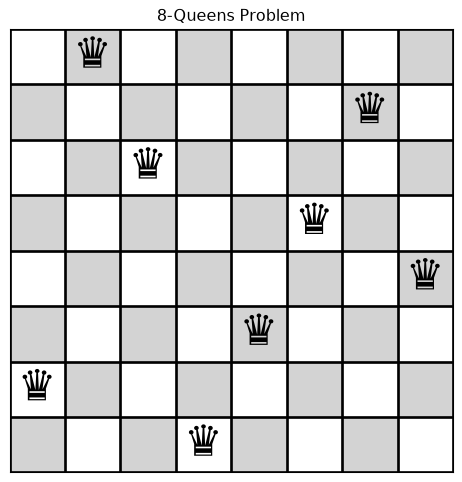

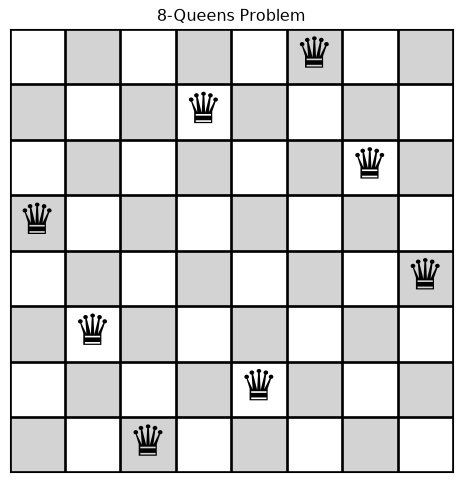

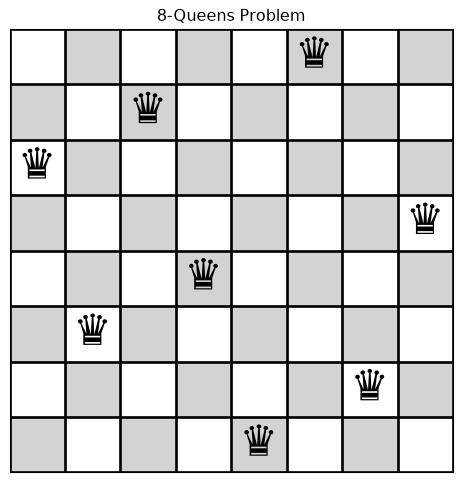

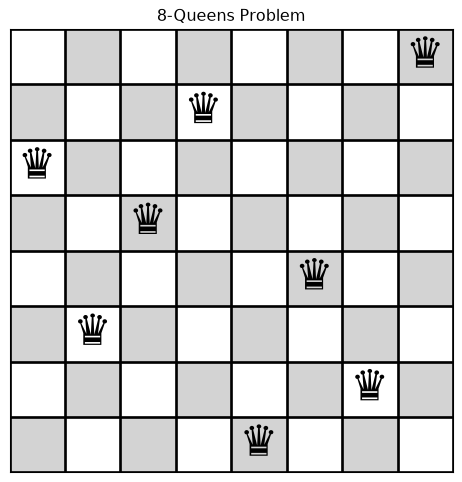

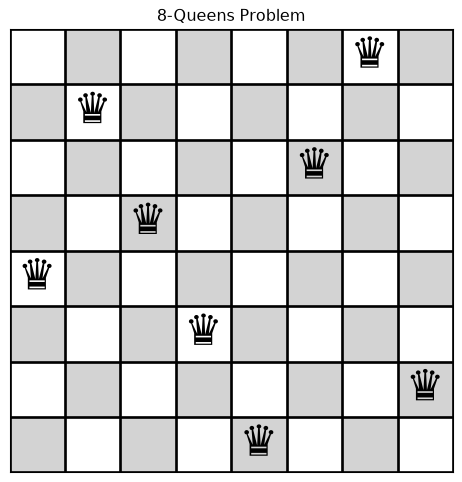

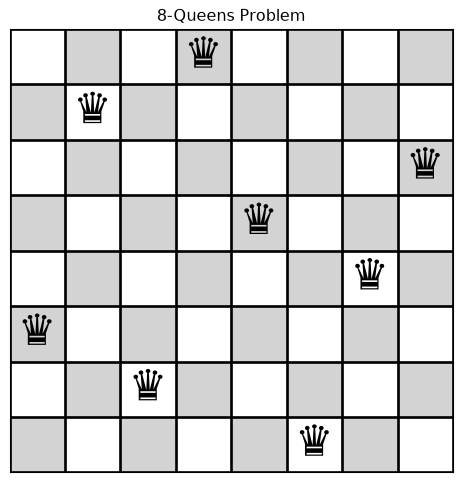

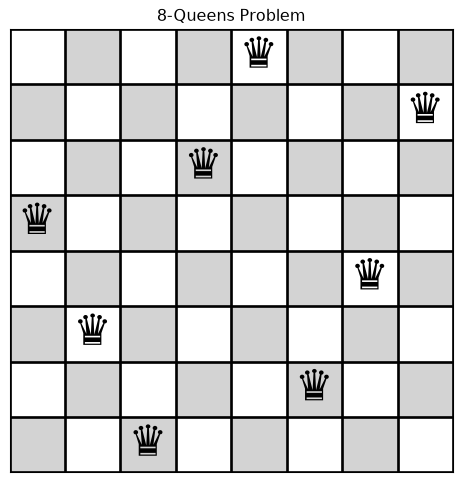

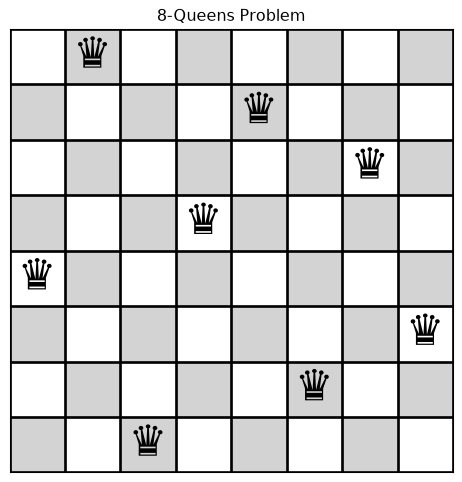

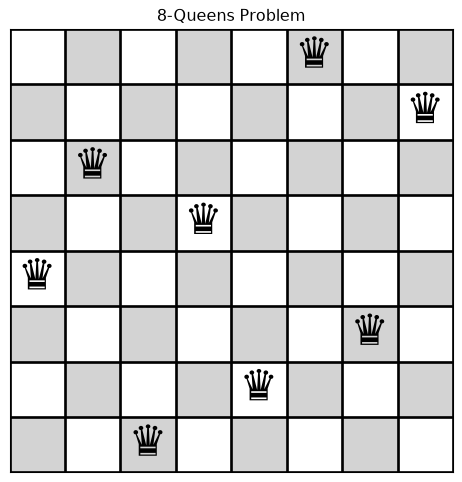

10 runs, number of solutions = 9, 0 duplicate(s)

In [22]:
random.seed(7)

solutions = 0

explored = set()
nb_duplicates = 0

for i in range(10):
  state = create_initial_state(8)

  new_state = hill_climbing(state)

  if (new_state != None):
    display_n_queens(new_state, 6)
    if tuple(new_state) in explored:
      nb_duplicates += 1
    solutions += 1

print(f"10 runs, number of solutions = {solutions}, {nb_duplicates} duplicate(s)")

## Solve (2)

In [23]:
random.seed(7)

solutions = 0

explored = set()
nb_duplicates = 0

nb_runs = 1000

for i in range(nb_runs):

  state = create_initial_state(8)

  new_state = hill_climbing(state)

  if (new_state != None):

    if tuple(new_state) in explored:
      nb_duplicates += 1
    else:
      explored.add(tuple(new_state))

    solutions += 1

print(f"{nb_runs} runs, number of solutions = {solutions}, {len(explored)} unique solutions")

1000 runs, number of solutions = 704, 92 unique solutions

## Solve 40-Queens

$40! = 8.1591528325 \times 10^{47}$

. . .

10 runs, number of solutions = 6, 6 unique solutions

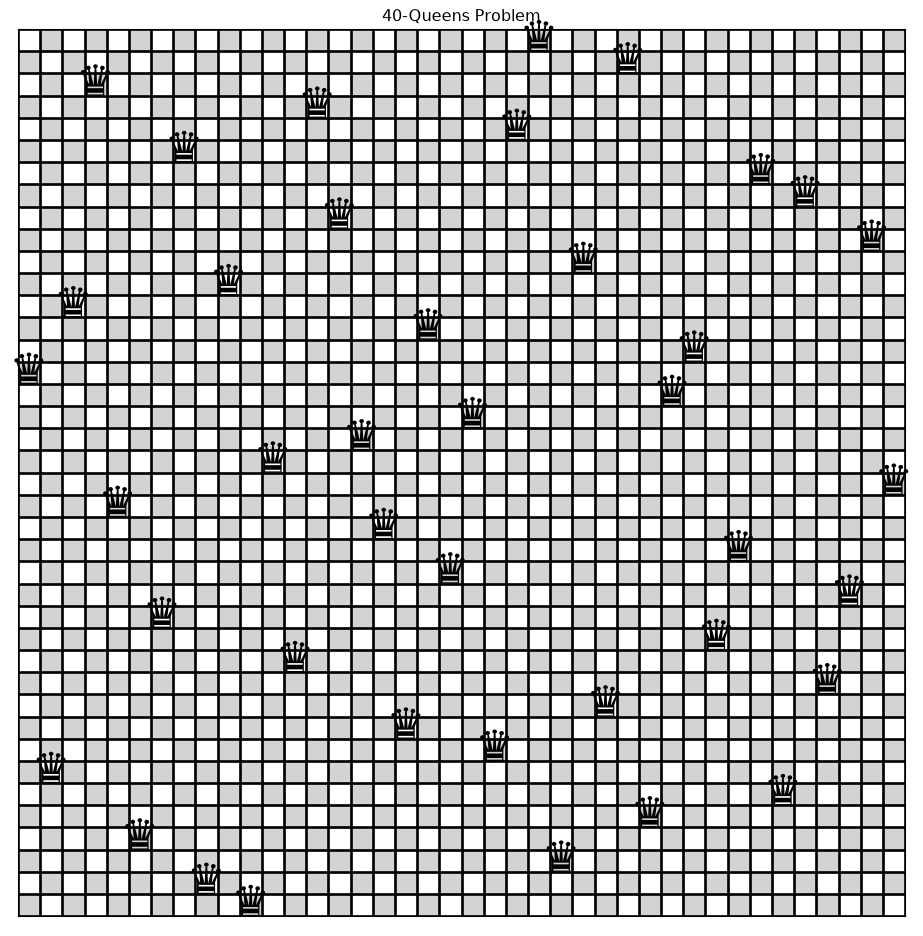

Elapsed time: 14.7658 seconds

In [25]:
import time

start_time = time.time()  # Record the start time

random.seed(7)

solutions = 0

explored = set()
nb_duplicates = 0

nb_runs = 10

for i in range(nb_runs):

  state = create_initial_state(40)

  new_state = hill_climbing(state)

  if (new_state != None):

    if tuple(new_state) in explored:
      nb_duplicates += 1
    else:
      explored.add(tuple(new_state))

    solutions += 1

print(f"{nb_runs} runs, number of solutions = {solutions}, {len(explored)} unique solutions")

one_board = next(iter(explored))
display_n_queens(one_board, 12)

end_time = time.time()  # Record the end time
elapsed_time = end_time - start_time  # Calculate the elapsed time

print(f"Elapsed time: {elapsed_time:.4f} seconds")

## Iterations and Side Moves

In [26]:
MAX_SIDE_MOVES = 100

def hill_climbing_counts(current_state):

    conflicts_current_state = calculate_conflicts(current_state)
    side_moves = 0
    iterations = 0

    while True:

        if conflicts_current_state == 0:
          return (iterations, side_moves, current_state)

        iterations += 1

        neighbors = get_neighbors(current_state)

        conflicts = [calculate_conflicts(voisin) for voisin in neighbors]

        if (min(conflicts)) > conflicts_current_state:
          return (iterations, side_moves, None)  # No improvement, local maxima

        if (min(conflicts)) == conflicts_current_state:
          side_moves += 1  # Plateau

        if side_moves > MAX_SIDE_MOVES:
          return (iterations, side_moves, None)

        arg_best = np.argmin(conflicts)
        current_state = neighbors[arg_best]
        conflicts_current_state = conflicts[arg_best]

In [27]:
random.seed(7)

solutions = 0

explored = set()
nb_duplicates = 0

nb_runs = 1000

iterations = []
sides = []

iterations_none = []
sides_none = []

for i in range(nb_runs):

  state = create_initial_state(8)

  (i, s, new_state) = hill_climbing_counts(state)

  if new_state != None:
    iterations.append(i)
    sides.append(s)
  else:
    iterations_none.append(i)
    sides_none.append(s)

  if new_state != None:

    if tuple(new_state) in explored:
      nb_duplicates += 1
    else:
      explored.add(tuple(new_state))

    solutions += 1

print(f"{nb_runs} runs, number of solutions = {solutions}, {len(explored)} unique solutions")

1000 runs, number of solutions = 704, 92 unique solutions

## Iterations and Side Moves

/var/folders/gh/zd7z03rs5dj7q_df5gz5jlmh0000gp/T/ipykernel_44668/2749126315.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()

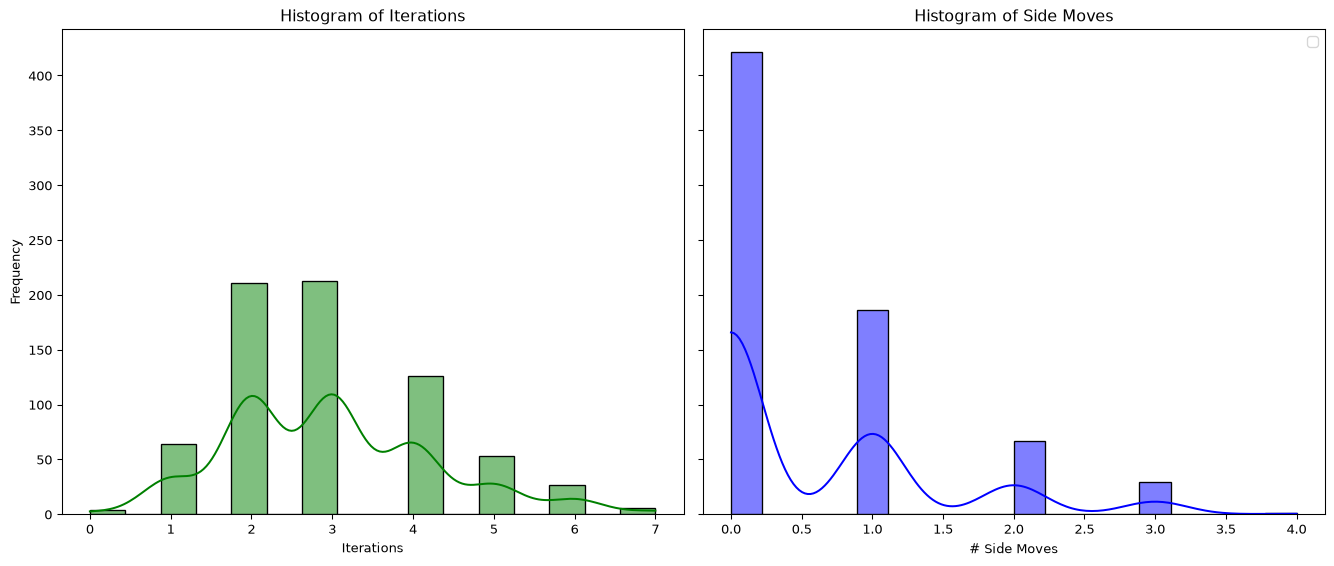

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

# Configurer la structure des sous-graphiques
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# Tracer l'histogramme pour `iterations`
sns.histplot(iterations, kde=True, color='green', ax=axes[0], edgecolor='black')
axes[0].set_title("Histogram of Iterations")
axes[0].set_xlabel("Iterations")
axes[0].set_ylabel("Frequency")

# Tracer l'histogramme pour `sides`
sns.histplot(sides, kde=True, color='blue', ax=axes[1], edgecolor='black')

axes[1].set_title("Histogram of Side Moves")
axes[1].set_xlabel("# Side Moves")

# Afficher le graphique
plt.legend()
plt.tight_layout()
plt.show()

## 20-Queens

In [29]:
random.seed(7)

solutions = 0

explored = set()
nb_duplicates = 0

nb_runs = 1000

iterations = []
sides = []

iterations_none = []
sides_none = []

for i in range(nb_runs):

  state = create_initial_state(20)

  (i, s, new_state) = hill_climbing_counts(state)

  if new_state != None:
    iterations.append(i)
    sides.append(s)
  else:
    iterations_none.append(i)
    sides_none.append(s)

  if new_state != None:

    if tuple(new_state) in explored:
      nb_duplicates += 1
    else:
      explored.add(tuple(new_state))

    solutions += 1

print(f"{nb_runs} runs, number of solutions = {solutions}, {len(explored)} unique solutions")

1000 runs, number of solutions = 566, 566 unique solutions

/var/folders/gh/zd7z03rs5dj7q_df5gz5jlmh0000gp/T/ipykernel_44668/2749126315.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()

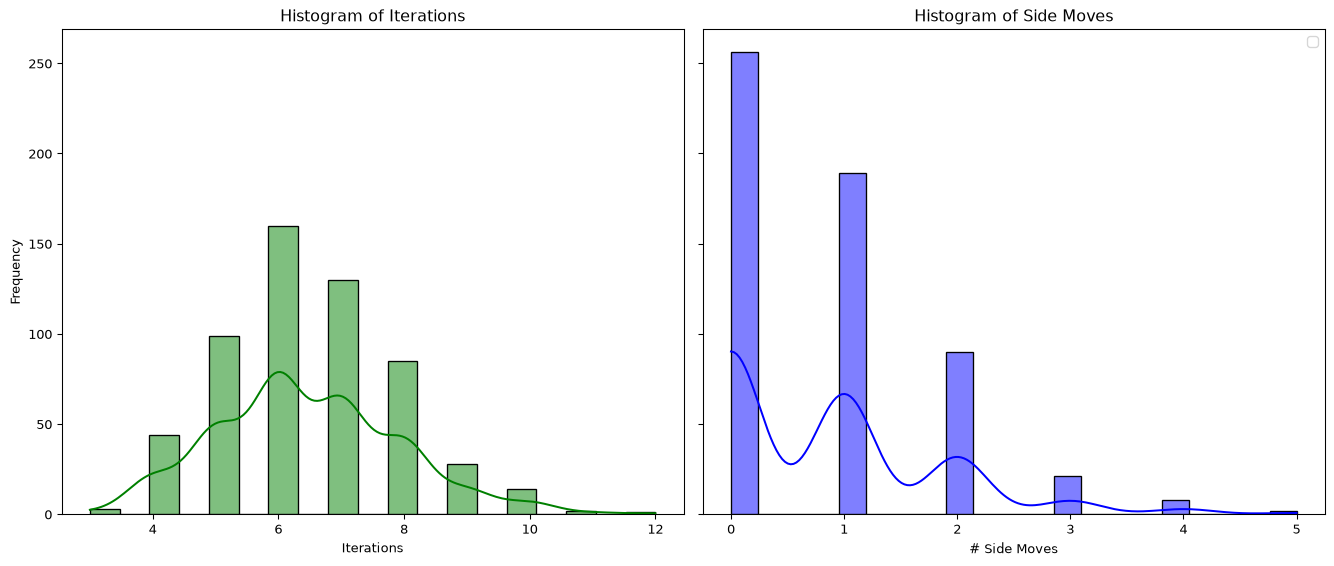

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

# Configurer la structure des sous-graphiques
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# Tracer l'histogramme pour `iterations`
sns.histplot(iterations, kde=True, color='green', ax=axes[0], edgecolor='black')
axes[0].set_title("Histogram of Iterations")
axes[0].set_xlabel("Iterations")
axes[0].set_ylabel("Frequency")

# Tracer l'histogramme pour `sides`
sns.histplot(sides, kde=True, color='blue', ax=axes[1], edgecolor='black')

axes[1].set_title("Histogram of Side Moves")
axes[1].set_xlabel("# Side Moves")

# Afficher le graphique
plt.legend()
plt.tight_layout()
plt.show()

## Russell & Norvig

- Hill climbing **gets stuck 86%** of the time.
  - Successful attempts average 4 steps to a solution.
- Permitting **100 lateral moves** boosts success rate from 14% to 94%.
- The problem space comprises $8^8 = 16,777,216$ states.
  - Implementation from Russell & Norvig

Has many variants, including **random-restart hill climbing**.

In the implementation I proposed, there do not appear to be any local
minima. However, this requires further verification.

## Escaping a Local Optimum

What mechanisms would enable the **hill climbing** algorithm to escape
from a local optimum, whether it be a local minimum or maximum?

It needs to accept going downhill.

A random walk approach, which disregards the value of the objective
function, could theoretically locate the global maximum. However, this
method is highly impractical due to its extreme inefficiency.

## Remark

Assume the optimization problem is a **minimization task**, where the
goal is to find a solution with the **minimum cost**.

Downhill, gradient descent.

# Simulated Annealing

## Definition

**Simulated annealing** is an optimization algorithm inspired by the
annealing process in metallurgy. It probabilistically explores the
solution space by allowing **occasional uphill moves**, which helps
**escape local optima**. The algorithm **gradually reduces the
probability of accepting worse solutions** by lowering a “temperature”
parameter, ultimately converging towards an optimal or near-optimal
solution.

## Annealing

>  **(Russell and Norvig 2020, 114)**
>
> In **metallurgy**, **annealing** is the process used to temper or
> harden metals and glass by **heating them to a high temperature** and
> **then gradually cooling them**, thus allowing the material to reach a
> **low-energy crystalline state**.

The solid is heated to its melting point, causing the particles to
become randomly distributed.

Subsequently, the material is gradually cooled, allowing the particles
to reorganize into a low-energy state.

## Algorithm

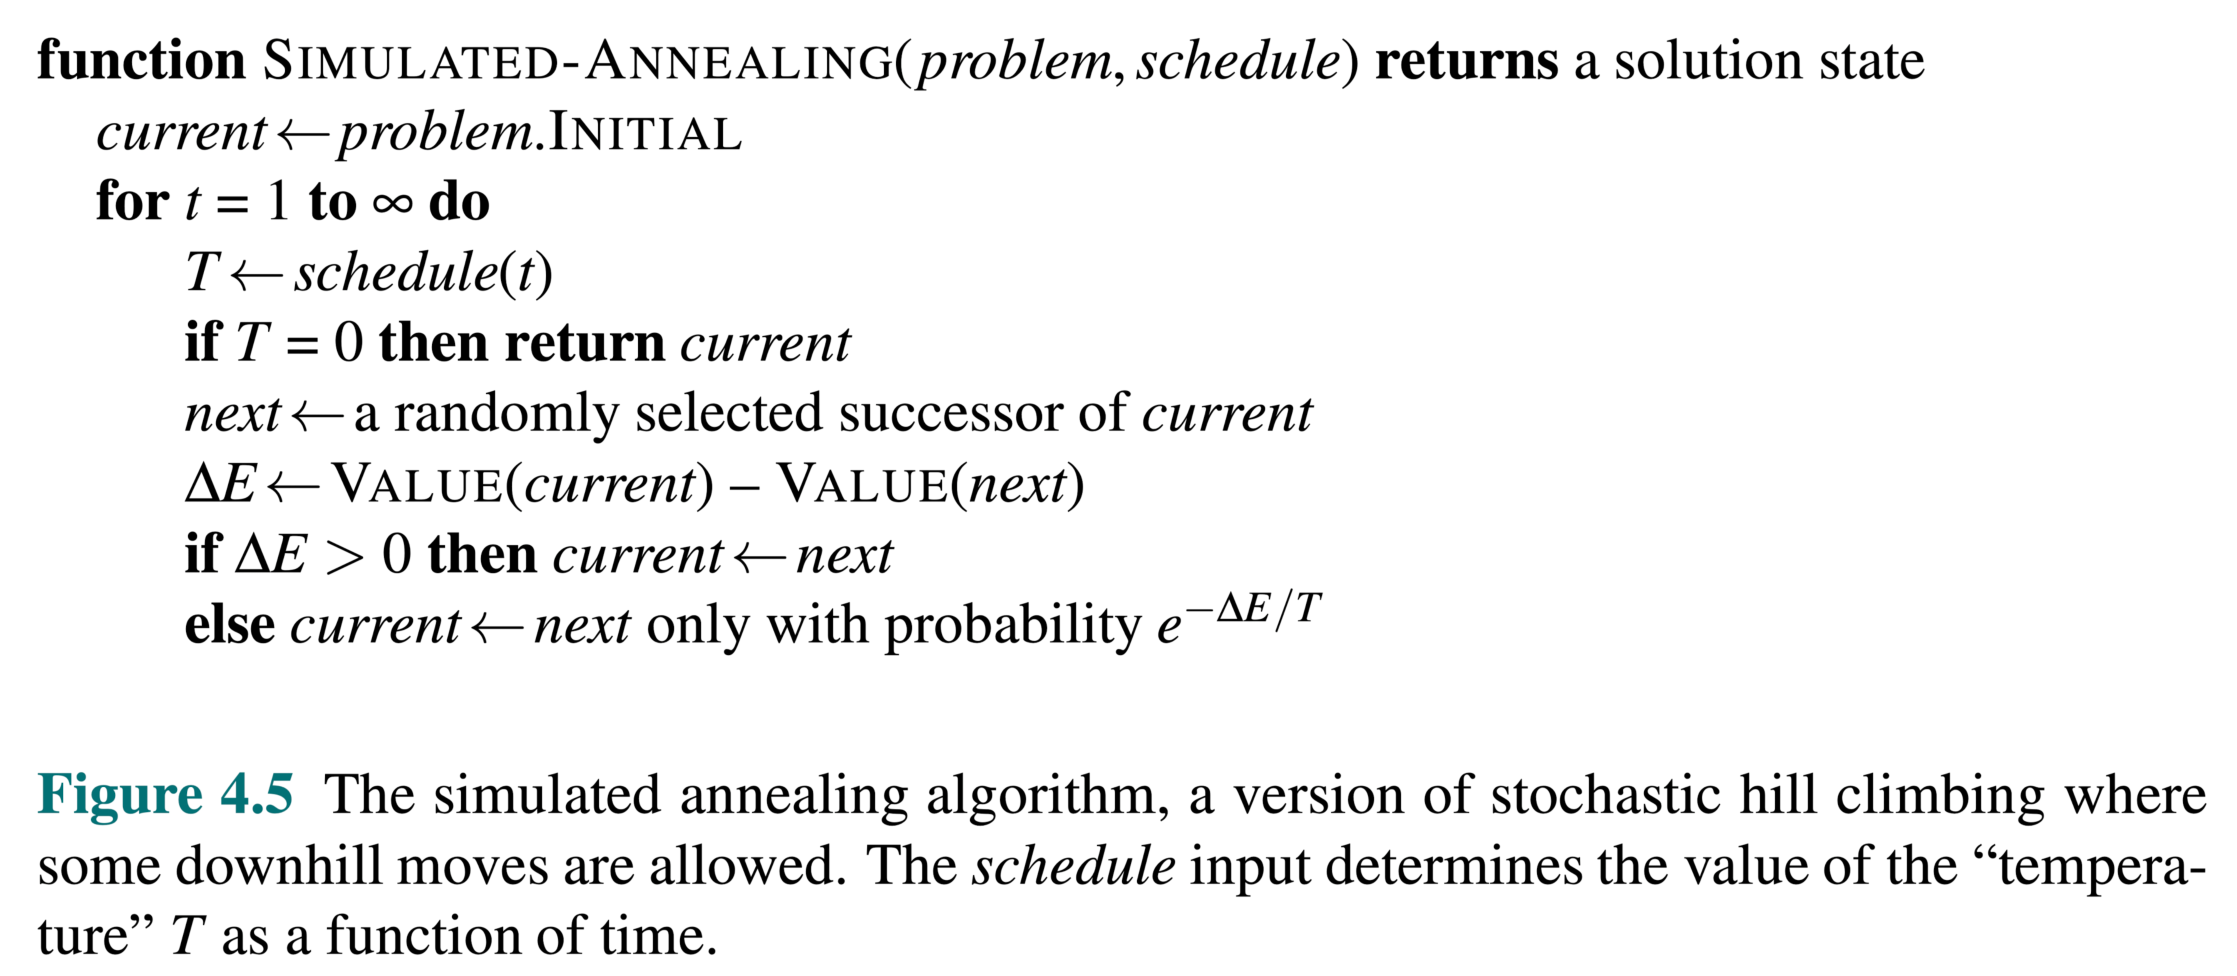

**Attribution**: (Russell and Norvig 2020, 115)

1.  This algorithm resembles hill climbing but differs by randomly
    selecting the next state rather than choosing the optimal move.

2.  If the move results in a lower objective function value, it is
    accepted unconditionally.

3.  Otherwise, acceptance is probabilistic, contingent on both
    $\Delta E$ and $T$.

## Varying $\Delta E$

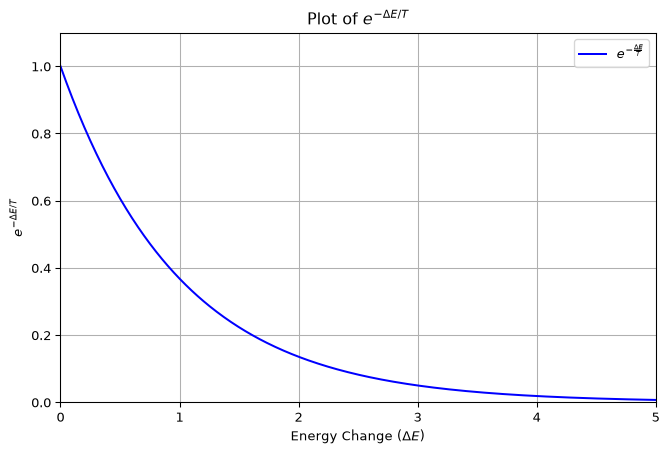

In [31]:
import numpy as np
import matplotlib.pyplot as plt

# Define a fixed temperature, T
T = 1.0  # You can adjust this value as needed

# Define a range of energy changes, ΔE
delta_E = np.linspace(0, 5, 500)

# Compute the function e^(-ΔE/T)
y = np.exp(-delta_E / T)

# Plot the function
plt.figure(figsize=(8, 5))
plt.plot(delta_E, y, label=r'$e^{-\frac{\Delta E}{T}}$', color='blue')
plt.title(r'Plot of $e^{-\Delta E / T}$')
plt.xlabel(r'Energy Change ($\Delta E$)')
plt.ylabel(r'$e^{-\Delta E / T}$')
plt.ylim(0, 1.1)
plt.xlim(0, 5)
plt.grid(True)
plt.legend()
plt.show()

Moves resulting in **significant negative changes** (worse) to the
objective function are **less likely to be accepted**.

## Varying the temperature, $T$

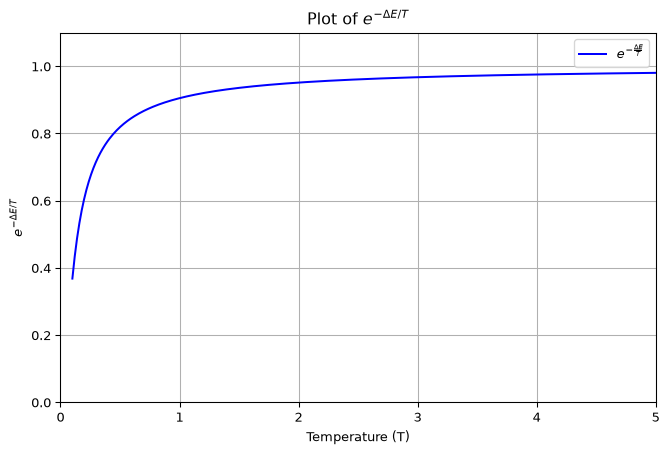

In [32]:
import numpy as np
import matplotlib.pyplot as plt

# Define the energy change, ΔE
delta_E = 0.1  # You can adjust this value as needed

# Define a range of temperatures, T
T = np.linspace(0.1, 5, 500)  # Avoid T=0 to prevent division by zero

# Compute the function e^(-ΔE/T)
y = np.exp(-delta_E / T)

# Plot the function
plt.figure(figsize=(8, 5))
plt.plot(T, y, label=r'$e^{-\frac{\Delta E}{T}}$', color='blue')
plt.title(r'Plot of $e^{-\Delta E / T}$')
plt.xlabel('Temperature (T)')
plt.ylabel(r'$e^{-\Delta E / T}$')
plt.ylim(0, 1.1)
plt.xlim(0, 5)
plt.grid(True)
plt.legend()
plt.show()

For a fixed $\Delta E$ (here $0.1$), changes are more likely to be
accepted whe $T$ is high, at the start of the algorithm.

## Varying the temperature and $\Delta E$

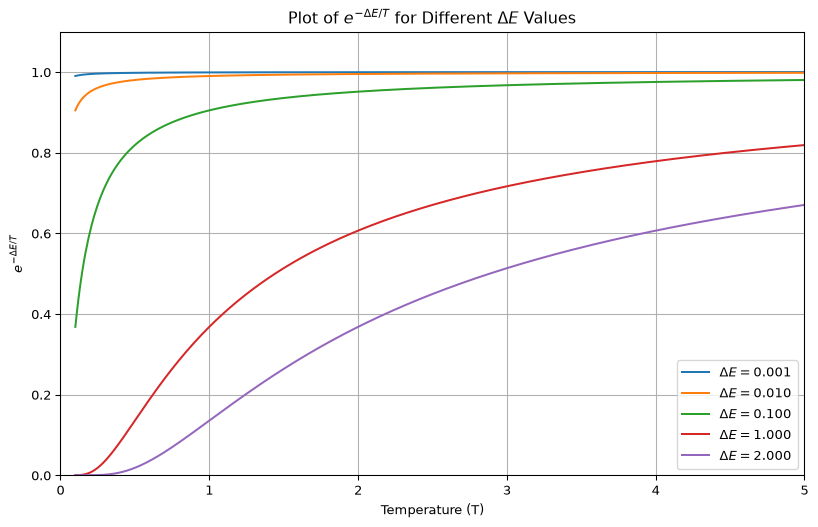

In [33]:
import numpy as np
import matplotlib.pyplot as plt

# Define a range of temperatures, T
T = np.linspace(0.1, 5, 500)  # Avoid T=0 to prevent division by zero

# Define specific values for energy change, ΔE
delta_E_values = [0.001, 0.01, 0.1, 1.0, 2.0]

# Plot the function for each ΔE
plt.figure(figsize=(10, 6))
for delta_E in delta_E_values:
    y = np.exp(-delta_E / T)
    plt.plot(T, y, label=r'$\Delta E = {:.3f}$'.format(delta_E))

# Customize the plot
plt.title(r'Plot of $e^{-\Delta E / T}$ for Different $\Delta E$ Values')
plt.xlabel('Temperature (T)')
plt.ylabel(r'$e^{-\Delta E / T}$')
plt.ylim(0, 1.1)
plt.xlim(0, 5)
plt.grid(True)
plt.legend()
plt.show()

Bad moves are more likely to be accepted at the start when $T$ is high,
and less likely as $T$ decreases.

## Varying the temperature and $\Delta E$

In [ ]:
import { Inputs, Plot } from "@observablehq/plot"

viewof deltaE = Inputs.range([0.01, 100], {step: 0.01, value: 0.1, label: "ΔE", width: 300})

T_values = Array.from({length: 1000}, (_, i) => (i + 1) * 0.1)

function computeData(deltaE) {
  return T_values.map(T => ({
    T: T,
    value: Math.exp(-deltaE / T)
  }))
}

data = computeData(deltaE)

Plot.plot({
  marks: [
    Plot.line(data, {
      x: "T", 
      y: "value", 
      stroke: "steelblue", 
      strokeWidth: 2
    }),
    Plot.ruleX([0], {stroke: "black"}), // X-axis line
    Plot.ruleY([0], {stroke: "black"})  // Y-axis line
  ]
})

Using **[Observable JS](https://observablehq.com/plot/)**.

## Theory

>  **(Russell and Norvig 2020, 114)**
>
> If the schedule lowers $T$ to 0 slowly enough, then a property of the
> **Boltzmann** (aka **Gibbs**) distribution, $e^{\frac{\Delta E}{T}}$,
> is that all the probability is concentrated on the global maxima,
> which the algorithm will find with probability approaching 1.

**See also:** Laarhoven and Aarts (1987), Aarts and Korst (1989),
Gendreau and Potvin (2019)

## Definition

The **Travelling Salesman Problem (TSP)** is a classic optimization
problem that seeks the shortest possible route for a salesman to visit a
set of cities, returning to the origin city, while visiting each city
exactly once.

The challenge lies in determining the most efficient path, especially as
the number of cities increases, due to the combinatorial explosion of
possible routes.

## Traveling Salesman

In [34]:
# Ensure we always generate the same coordinates

np.random.seed(42)

# Generate random coordinates for the cities

num_cities = 20
coordinates = np.random.rand(num_cities, 2) * 100

# Calculate the distance matrix

distance_matrix = np.sqrt(((coordinates[:, np.newaxis] - coordinates[np.newaxis, :]) ** 2).sum(axis=2))

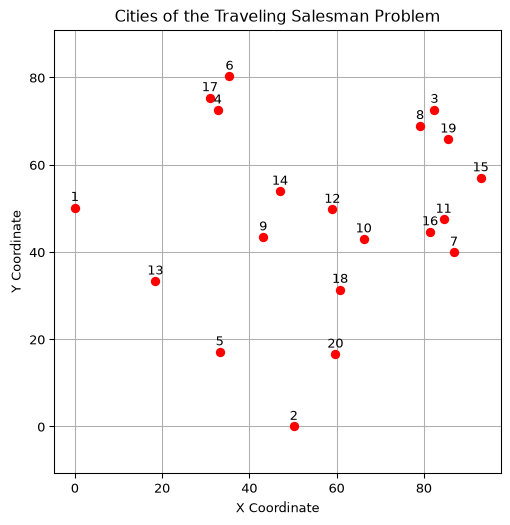

In [35]:
import matplotlib.pyplot as plt

def plot_cities(coordinates, title="Cities of the Traveling Salesman Problem"):

    """
    Plot the given coordinates representing the cities.
    
    Parameters:
    - coordinates: A 2D NumPy array of shape (n, 2) representing the (x, y) coordinates.
    - title: Title of the plot.
    """

    # Extract x and y coordinates
    x = coordinates[:, 0]
    y = coordinates[:, 1]

    plt.figure(figsize=(6, 6))

    # Plot the cities as red points
    plt.scatter(x, y, c='red', zorder=2)

    # Annotate the cities with their indices
    for i, (xi, yi) in enumerate(zip(x, y)):
        plt.annotate(str(i + 1), (xi, yi), textcoords="offset points", xytext=(0, 5), ha='center')

    # Set the title and labels
    plt.title(title)
    plt.xlabel('X Coordinate')
    plt.ylabel('Y Coordinate')
    plt.grid(True)
    plt.axis('equal')  # Equal scaling for x and y axes
    plt.show()

plot_cities(distance_matrix)

## How to Represent a Solution?

. . .

We will use a **list** where each element represents the index of a
city, and the order of elements indicates the **sequence of city
visits**.

## Random Solution

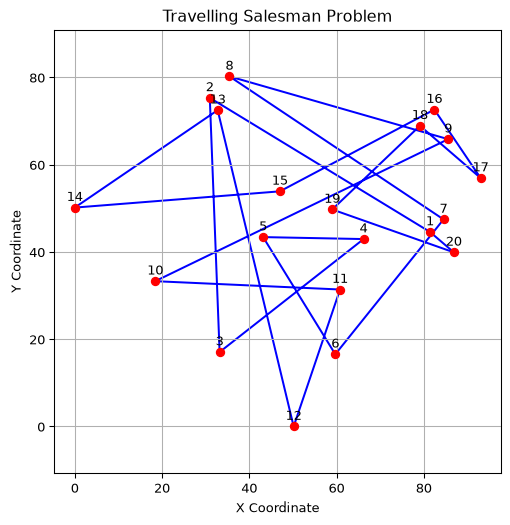

In [36]:
def plot_tsp_path(coordinates, path=None, title="Travelling Salesman Problem"):

    """
    Plots the given coordinates and optionally a path for the TSP.
    
    Parameters:
    - coordinates: A 2D NumPy array of shape (n, 2) representing the (x, y) coordinates.
    - path: A list or array of indices representing the order of cities to visit. If None, the nodes are connected in input order.
    - title: Title of the plot.
    """

    # Extract x and y coordinates
    x = coordinates[:, 0]
    y = coordinates[:, 1]

    plt.figure(figsize=(6, 6))

    # If a path is given, rearrange the coordinates
    if path is not None:
        x = x[path]
        y = y[path]
    
    # Plot the nodes
    plt.scatter(x, y, c='red', zorder=2)

    # Annotate the nodes with their indices
    for i, (xi, yi) in enumerate(zip(x, y)):
        plt.annotate(str(i + 1), (xi, yi), textcoords="offset points", xytext=(0, 5), ha='center')

    # Plot the path
    plt.plot(x, y, 'b-', zorder=1)

    # If a path is provided, connect the last point to the first to complete the tour
    if path is not None:
        plt.plot([x[-1], x[0]], [y[-1], y[0]], 'b-', zorder=1)

    # Set the title and labels
    plt.title(title)
    plt.xlabel('X Coordinate')
    plt.ylabel('Y Coordinate')
    plt.grid(True)
    plt.axis('equal')  # Equal scale for x and y axes
    plt.show()

num_cities = len(distance_matrix)
current_route = np.arange(num_cities)
np.random.shuffle(current_route)
plot_tsp_path(distance_matrix, current_route)

## Calculate the Total Distance

In [37]:
# Function to calculate the total distance of a given route

def calculate_total_distance(route, distance_matrix):

    total_distance = 0

    for i in range(len(route) - 1):
        total_distance += distance_matrix[route[i], route[i + 1]]

    total_distance += distance_matrix[route[-1], route[0]]  # Back to start

    return total_distance

## Neighborhood

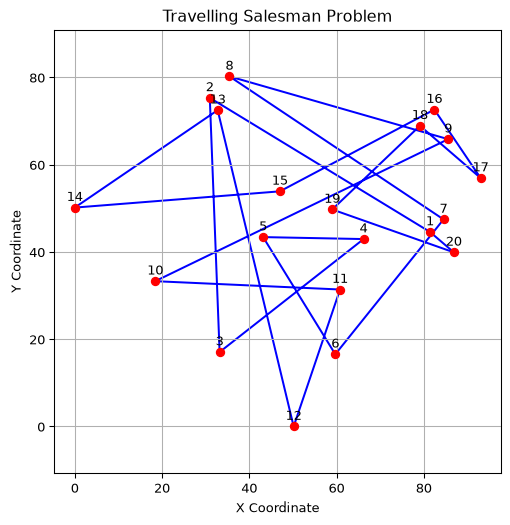

In [38]:
plot_tsp_path(distance_matrix,current_route)

**How** to generate a neighboring solution?

## Generating a Neighboring Solution

**How** to generate a neighboring solution?

## Swap Two Cities

- **Description**: Select two cities at random and swap their positions.
- **Pros**: Simple and effective for exploring nearby solutions.
- **Cons**: Change may be too small, potentially slowing down
  convergence.

## Reverse Segment

- **Description**: Select two indices and reverse the segment between
  them.
- **Pros**: More effective at finding shorter paths compared to simple
  swaps.
- **Cons**: Can still be computationally expensive as the number of
  cities increases.

## Remove & Reconnect

- **Description**: Removes three edges from the route and reconnects the
  segments in the best possible way. This can generate up to 7 different
  routes.
- **Pros**: Provides more extensive changes and can escape local optima
  more effectively than 2-opt.
- **Cons**: More complex and computationally expensive to implement.

## Insertion Move

- **Description**: Select a city and move it to a different position in
  the route.
- **Pros**: Offers a balance between small and large changes, making it
  useful for fine-tuning solutions.
- **Cons**: May require more iterations to converge to an optimal
  solution.

## Shuffle Subset

- **Description**: Select a subset of cities in the route and randomly
  shuffle their order.
- **Pros**: Introduces larger changes and can help escape local minima.
- **Cons**: Can lead to less efficient routes if not handled carefully.

## Generating a Neighboring Solution

In [39]:
# Function to generate a random neighboring solution

def get_neighbor(route):

    a, b = np.random.randint(0, len(route), size=2)

    if a > b:
        a, b = b, a

    new_route = route.copy()
    new_route[a:b+1] = new_route[a:b+1][::-1]  # Reverse the segment between a and b
    
    return new_route

## `simulated_annealing`

In [40]:
def simulated_annealing(distance_matrix, initial_temp, cooling_rate, max_iterations):

    num_cities = len(distance_matrix)
    current_route = np.arange(num_cities)
    np.random.shuffle(current_route)
    current_cost = calculate_total_distance(current_route, distance_matrix)
    
    best_route = current_route.copy()
    best_cost = current_cost

    temperature = initial_temp

    for iteration in range(max_iterations):

        neighbor_route = get_neighbor(current_route)
        neighbor_cost = calculate_total_distance(neighbor_route, distance_matrix)
        
        # Accept the neighbor if it is better, or with a probability if it is worse.

        delta_E = neighbor_cost - current_cost

        if neighbor_cost < current_cost or np.random.rand() < np.exp(-(delta_E)/temperature):
            current_route = neighbor_route
            current_cost = neighbor_cost

            if current_cost < best_cost:
                best_route = current_route.copy()
                best_cost = current_cost

        # Cool down the temperature
        temperature *= cooling_rate

    return best_route, best_cost, temperatures, costs

## Remarks

- As $t \to \infty$, the algorithm exhibits behavior characteristic of a
  **random walk**. During this phase, any neighboring state, regardless
  of whether it improves the objective function, is accepted. This
  facilitates exploration and occurs at the start of the algorithm’s
  execution.

## Remarks

- Conversely, as $t \to 0$, the algorithm behaves like **hill
  climbing**. In this phase, only those states that enhance the
  objective function’s value are accepted, ensuring that the algorithm
  consistently moves towards optimal solutions—specifically, towards
  lower values in minimization problems. This phase emphasizes the
  exploitation of promising solutions and occurs towards the algorithm’s
  conclusion.

**See also**: [Properties of Simulated Annealing - Georgia Tech -
Machine Learning](https://youtu.be/enNgiWuIHAo). Udacity video (4m 10s).
Posted on 2015-02-23.

1.  **Exploration**:
    - Exploration involves searching through a broad area of the search
      space to discover new possibilities, solutions, or information.
      The goal of exploration is to gather a diverse set of data points
      or solutions that could potentially lead to finding better global
      optima. It prevents the search process from getting trapped in
      local optima by encouraging the consideration of less-visited or
      unexplored regions of the search space.
    - In algorithms, exploration can be implemented by introducing
      randomness, trying new or less-promising paths, or using
      strategies like simulated annealing or genetic algorithms that
      encourage diversity.
2.  **Exploitation**:
    - Exploitation focuses on leveraging known information to refine and
      improve existing solutions. It involves concentrating the search
      effort around areas believed to contain high-quality solutions
      based on prior knowledge or experience. The goal is to optimize
      and fine-tune these solutions to achieve the best possible outcome
      in those regions.
    - In algorithms, exploitation can be seen in strategies like hill
      climbing, gradient ascent/descent, or greedy algorithms, where the
      search is focused on local improvement and making incremental
      gains.

## Example

In [41]:
# Ensuring reproducibility
np.random.seed(42)

# Generate random coordinates for cities
num_cities = 20
coordinates = np.random.rand(num_cities, 2) * 100

# Calculate distance matrix
distance_matrix = np.sqrt(((coordinates[:, np.newaxis] - coordinates[np.newaxis, :]) ** 2).sum(axis=2))

# Run simulated annealing

initial_temp = 15
cooling_rate = 0.995
max_iterations = 1000

## Held–Karp Algorithm

- **Introduced**: 1962 by Held, Karp, and independently by Bellman.
- **Problem**: Solves the Traveling Salesman Problem (TSP) using
  **dynamic programming**.
- **Time Complexity**: $\Theta(2^n n^2)$.
- **Space Complexity**: $\Theta(2^n n)$.
- **Efficiency**: Better than brute-force $\Theta(n!)$, yet still
  **exponential**.

## Held–Karp Algorithm

In [42]:
from itertools import combinations
import numpy as np

def held_karp(distance_matrix):
    # Number of cities
    n = len(distance_matrix)

    # DP table: dp[subset][last_visited] = minimum cost to reach `last_visited` with `subset` of cities visited
    dp = {}

    # Initialize the DP table with the distances from the starting point (city 0)
    for i in range(1, n):
        dp[(1 << i, i)] = distance_matrix[0][i]

    # Iterate over all subset sizes
    for subset_size in range(2, n):
        for subset in combinations(range(1, n), subset_size):
            # Bitmask of the subset, excluding the starting city
            subset_mask = sum(1 << i for i in subset)
            for last in subset:
                # Update the DP table with the minimum cost for this subset and last city
                prev_subset_mask = subset_mask & ~(1 << last)
                dp[(subset_mask, last)] = min(
                    dp[(prev_subset_mask, k)] + distance_matrix[k][last]
                    for k in subset if k != last
                )

    # Find the minimum cost to complete the tour back to the starting point (city 0)
    full_mask = (1 << n) - 2  # All cities visited except starting city
    return min(dp[(full_mask, last)] + distance_matrix[last][0] for last in range(1, n))

# Example usage with a sample distance matrix
# distance_matrix = [
#     [0, 10, 15, 20],
#     [10, 0, 35, 25],
#     [15, 35, 0, 30],
#     [20, 25, 30, 0]
# ]
min_cost = held_karp(distance_matrix)
print(f"Using Held–Karp to find the minimum cost of TSP tour: {min_cost:.2f}")

Using Held–Karp to find the minimum cost of TSP tour: 386.43

Held and Karp (1962) and Bellman (1962)

## Execution

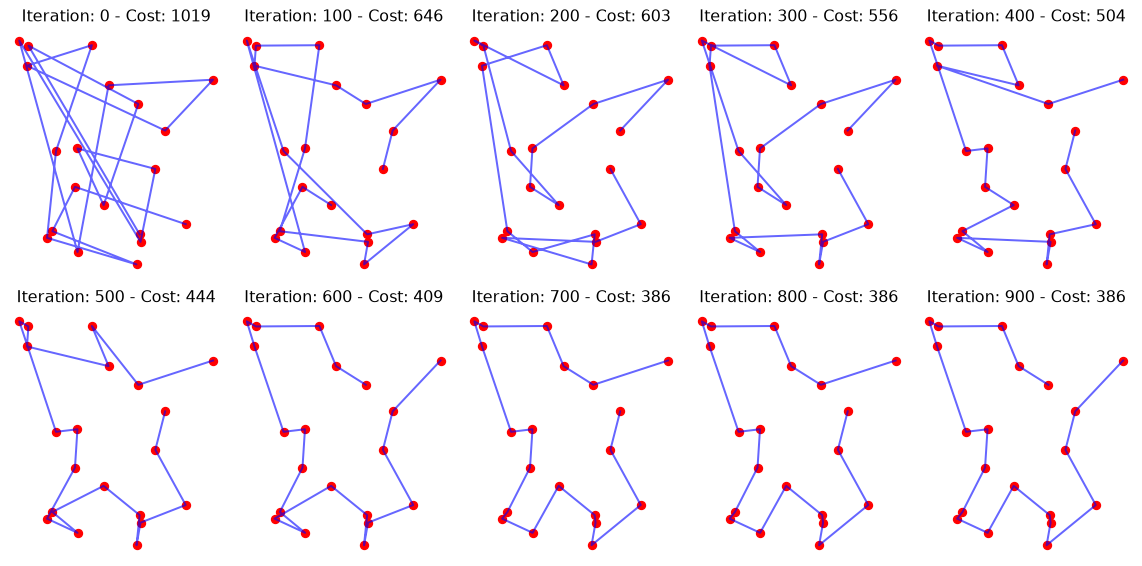

In [43]:
# Simulated Annealing function

def simulated_annealing(distance_matrix, initial_temp, cooling_rate, max_iterations):
    num_cities = len(distance_matrix)
    current_route = np.arange(num_cities)
    np.random.shuffle(current_route)
    current_cost = calculate_total_distance(current_route, distance_matrix)
    
    best_route = current_route.copy()
    best_cost = current_cost

    temperatures = []
    costs = []

    temperature = initial_temp

    # Collect intermediate solutions
    intermediate_solutions = []
    for iteration in range(max_iterations):
        neighbor_route = get_neighbor(current_route)
        neighbor_cost = calculate_total_distance(neighbor_route, distance_matrix)
        
        # Accept neighbor if it's better, or with a probability if it's worse
        if neighbor_cost < current_cost or np.random.rand() < np.exp(-(neighbor_cost - current_cost) / temperature):
            current_route = neighbor_route
            current_cost = neighbor_cost

            if current_cost < best_cost:
                best_route = current_route.copy()
                best_cost = current_cost

        # Store temperature and cost for plotting
        temperatures.append(temperature)
        costs.append(current_cost)

        # Cool down the temperature
        temperature *= cooling_rate

        # Collect intermediate solutions at regular intervals
        if iteration % (max_iterations // 10) == 0:
            intermediate_solutions.append((current_route.copy(), current_cost))

    # Plot 10 intermediate solutions in a 4x5 grid
    fig, axes = plt.subplots(2, 5, figsize=(12, 6))
    axes = axes.flatten()
    for idx, (route, cost) in enumerate(intermediate_solutions):
        ax = axes[idx]
        ax.scatter(*zip(*coordinates), c='red', marker='o')
        ax.plot(*zip(*coordinates[route]), 'b-', alpha=0.6)
        ax.set_title(f"Iteration: {idx*100} - Cost: {cost:.0f}")
        ax.axis('off')  # Turn off the axes for a cleaner look
    plt.tight_layout()
    plt.show()

    return best_route, best_cost, temperatures, costs


best_route, best_cost, temperatures, costs = simulated_annealing(distance_matrix, initial_temp, cooling_rate, max_iterations)

When I initially published these slides, the selected initial
temperature of 1000 was excessively high relative to the objective
function’s cost. By adjusting the initial temperature to 15, we achieve
a more effective balance between exploration and exploitation.

Due to the snapshots being captured every 100 iterations, the increases
in cost are not visible. This is illustrated on the “Temperature and
Cost” slide.

## Best Route

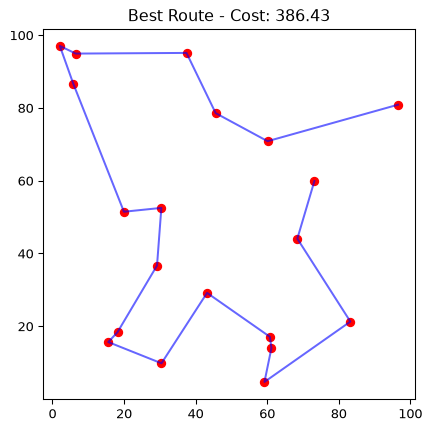

In [44]:
# Plot the final best route
plt.figure(figsize=(5, 5))
plt.scatter(*zip(*coordinates), c='red', marker='o')
plt.plot(*zip(*coordinates[best_route]), 'b-', alpha=0.6)
plt.title(f"Best Route - Cost: {best_cost:.2f}")
plt.show()

We have found an **optimal tour**!

## Temperature and Cost

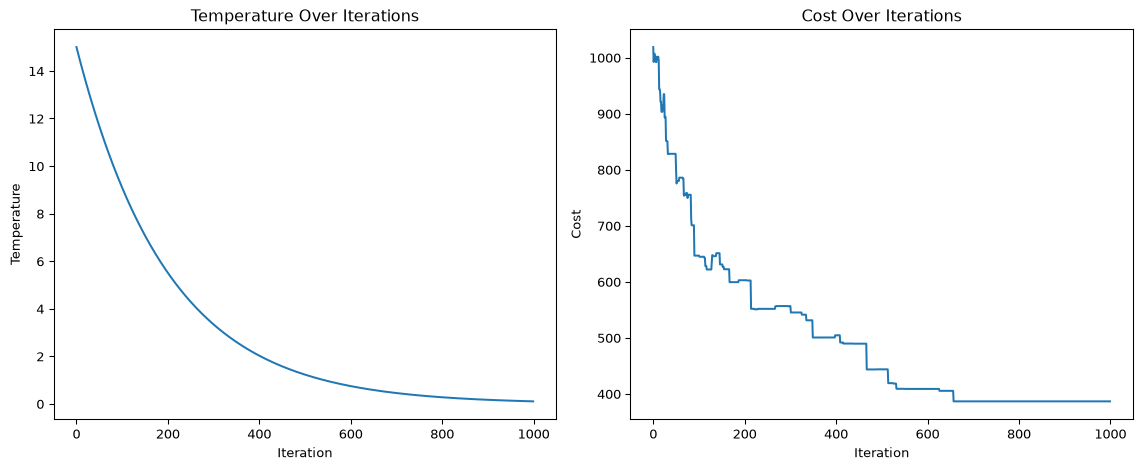

In [45]:
# Plot temperature and cost graphs
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(temperatures)
plt.title("Temperature Over Iterations")
plt.xlabel("Iteration")
plt.ylabel("Temperature")

plt.subplot(1, 2, 2)
plt.plot(costs)
plt.title("Cost Over Iterations")
plt.xlabel("Iteration")
plt.ylabel("Cost")

plt.tight_layout()
plt.show()

## Swapping Neighbors

- **Description**: Select two cities at random, swap their positions.
- **Pros**: Simple and effective for exploring nearby solutions.
- **Cons**: Change may be too small, potentially slowing down
  convergence.

In [46]:
def get_neighbor_swap(route):
    a, b = np.random.randint(0, len(route), size=2)
    new_route = route.copy()
    new_route[a], new_route[b] = new_route[b], new_route[a]
    return new_route

## Execution

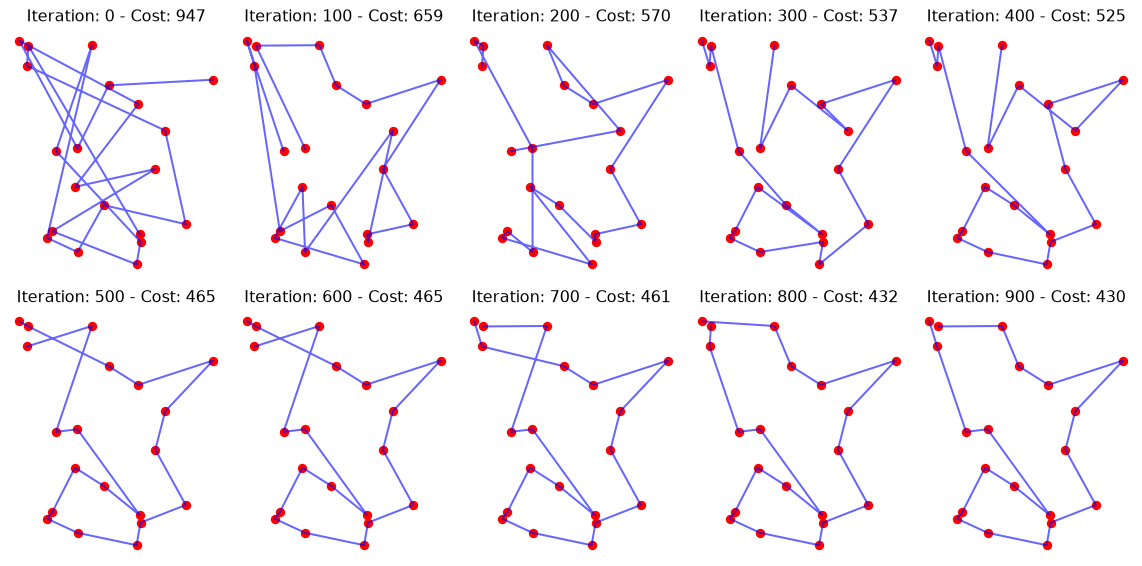

In [47]:
# Plot the final best route
get_neighbor = get_neighbor_swap

best_route, best_cost, temperatures, costs = simulated_annealing(distance_matrix, initial_temp, cooling_rate, max_iterations)

## Best Route

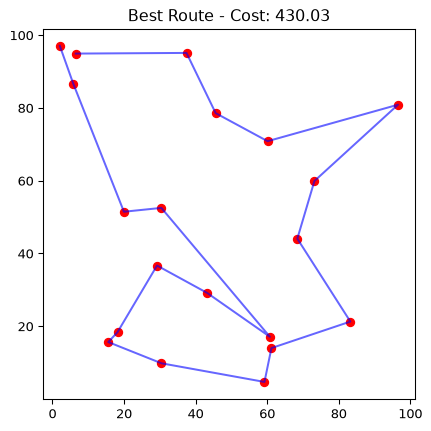

In [48]:
# Plot the final best route
plt.figure(figsize=(5, 5))
plt.scatter(*zip(*coordinates), c='red', marker='o')
plt.plot(*zip(*coordinates[best_route]), 'b-', alpha=0.6)
plt.title(f"Best Route - Cost: {best_cost:.2f}")
plt.show()

In this specific instance and for the given problem, **reverse segment**
(cost = 386.43) was more effective compared to **swapping neighbors**
(cost = 430.03).

## Temperature and Cost

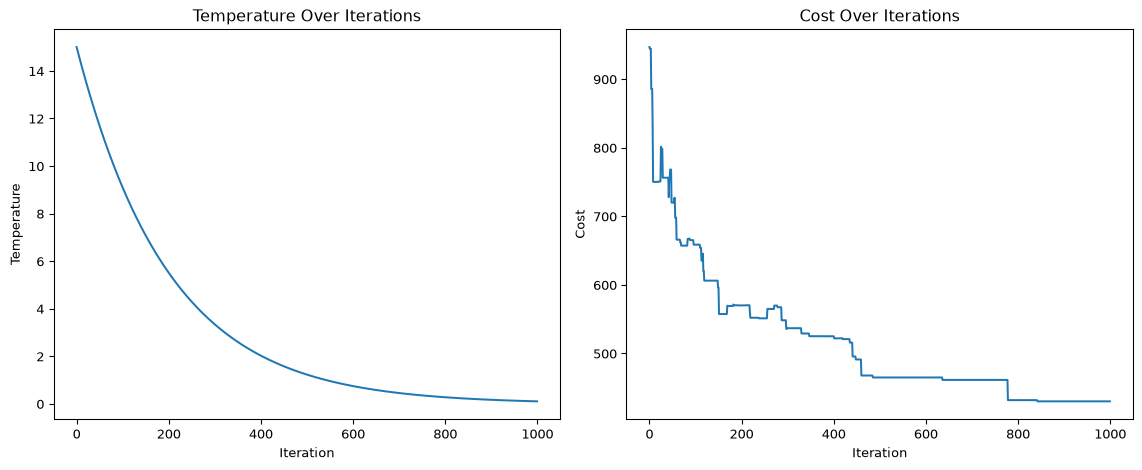

In [49]:
# Plot temperature and cost graphs
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(temperatures)
plt.title("Temperature Over Iterations")
plt.xlabel("Iteration")
plt.ylabel("Temperature")

plt.subplot(1, 2, 2)
plt.plot(costs)
plt.title("Cost Over Iterations")
plt.xlabel("Iteration")
plt.ylabel("Cost")

plt.tight_layout()
plt.show()

## Selecting a Neighborhood Strategy

- **Simple Moves (Swap, Insertion)**: Effective for initial exploration;
  risk of local optima entrapment.

- **Complex Moves**: Enhance capability to escape local optima and
  accelerate convergence; entail higher computational expense.

- **Hybrid Approaches**: Integrate diverse strategies for neighborhood
  generation. Employ simple moves initially, transitioning to complex
  ones as convergence progresses.

## Initial Temperature

**Influence**: Since the probability of accepting a new state is given
by $e^{-\frac{\Delta E}{T}}$, the selection of the **initial
temperature** is directly influenced by $\Delta E$ and consequently by
the **objective function value for a random state**, $f(s)$.

## Initial Temperature

- **Example Problems**: Consider two scenarios: problem $a$ with
  $f(a) = 1,000$ and problem $b$ with $f(b) = 100$.

- **Energy Difference**: Accepting a state that is 10% worse results in
  energy differences $\Delta E = 0.1 \cdot f(a) = 100$ for problem $a$
  and $\Delta E = 0.1 \cdot f(b) = 10$ for problem $b$.

- **Acceptance Probability**: To accept such state 60% of the time, set
  $e^{-\frac{\Delta E}{T}} = 0.6$. Solving for $T$ yields initial
  temperatures of approximately $T \approx 195.8$ for problem $a$ and
  $T \approx 19.58$ for problem $b$.

## Initial Temperature

A **popular approach** is to set the initial temperature so that a
**significant portion of moves (often around 60-80%) are accepted**.

This can be done by running a preliminary phase where the temperature is
adjusted until the acceptance ratio stabilizes within this range.

Ben-Ameur (2004) suggests a more rigorous mathematical methodology.

## Cooling Strategies

In **simulated annealing**, cooling down is essential for managing
algorithm convergence. The cooling schedule dictates the rate at which
the temperature decreases, affecting the algorithm’s capacity to
**escape local optima** and **converge towards a near-optimal
solution**.

Nourani and Andresen (1998) and Alex et al. (2017)

## Linear Cooling

- **Description**: The temperature decreases linearly with each
  iteration.
- **Formula**: $T = T_0 - \alpha \cdot k$
  - $T_0$: Initial temperature
  - $\alpha$: A constant decrement
  - $k$: Current iteration
- **Pros**: Simple to implement and understand.
- **Cons**: Often leads to **premature convergence** because the
  temperature decreases too quickly.

In [50]:
temperature = initial_temp - alpha * iteration

## Geometric (Exponential) Cooling

- **Description**: The temperature decreases exponentially with each
  iteration.
- **Formula**: $T = T_0 \cdot \alpha^k$
  - $\alpha$: Cooling rate, typically between 0.8 and 0.99
  - $k$: Current iteration
- **Pros**: Widely used due to its simplicity and effectiveness.
- **Cons**: The choice of $\alpha$ is critical; if it’s too small, the
  temperature drops too fast, and if it’s too large, convergence can be
  slow.

In [51]:
temperature = initial_temp * (cooling_rate ** iteration)

## Logarithmic Cooling

- **Description**: The temperature decreases slowly following a
  logarithmic function.
- **Formula**: $T = \frac{\alpha \cdot T_0}{\log(1+k)}$
  - $\alpha$: A scaling constant
  - $k$: Current iteration
- **Pros**: Provides a slower cooling rate, which is useful for problems
  that require extensive exploration of the solution space.
- **Cons**: Convergence can be very slow, requiring many iterations.

In [52]:
temperature = alpha * initial_temp / (np.log(1 + iteration))

## Inverse Cooling

- **Description**: The temperature decreases as an inverse function of
  the iteration number.
- **Formula**: $T = \frac{T_0}{1+\alpha \cdot K}$
  - $\alpha$: A scaling constant
  - $k$: Current iteration
- **Pros**: Allows for a more controlled cooling process, balancing
  exploration and exploitation.
- **Cons**: May require careful tuning of $\alpha$ to be effective.

In [53]:
temperature = initial_temp / (1 + alpha * iteration)

## Adaptive Cooling

- **Description**: The cooling schedule is adjusted dynamically based on
  the performance of the algorithm.
- **Strategy**: If the algorithm is not making significant progress, the
  cooling rate may be slowed down. Conversely, if progress is steady,
  the cooling rate can be increased.
- **Pros**: More flexible and can adapt to the characteristics of the
  problem.
- **Cons**: More complex to implement and requires careful design to
  avoid instability.

In [54]:
if no_significant_change_in_cost:
    temperature *= 0.99  # Slow down cooling
else:
    temperature *= 0.95  # Speed up cooling

## Cooling Schedule - Summary

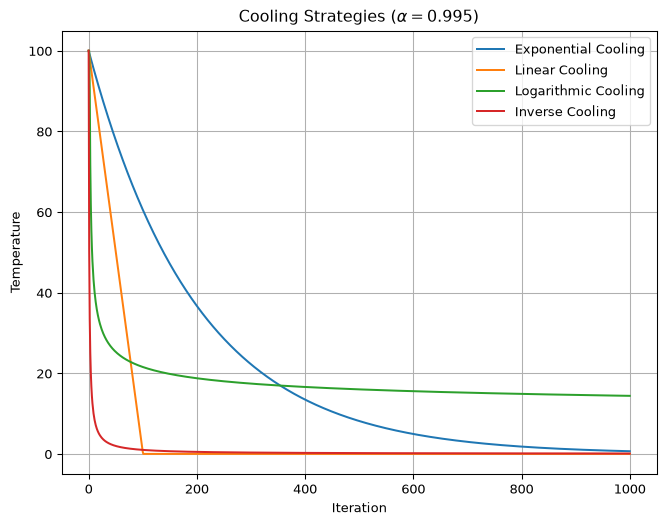

In [55]:
# Constants
initial_temp = 100
alpha = 0.995
iterations = np.arange(0, 1001)

# Cooling strategies
def exponential_cooling(initial_temp, alpha, iteration):
    return initial_temp * (alpha ** iteration)

def linear_cooling(initial_temp, alpha, iteration):
    return max(0, initial_temp - alpha * iteration)

def logarithmic_cooling(initial_temp, alpha, iteration):
    return min(initial_temp, alpha * initial_temp / (np.log(1 + iteration) + 10e-9))

def inverse_cooling(initial_temp, alpha, iteration):
    return initial_temp / (1 + alpha * iteration)

# Calculate temperatures
linear_temps = [linear_cooling(initial_temp, alpha, i) for i in iterations]
exponential_temps = [exponential_cooling(initial_temp, alpha, i) for i in iterations]
logarithmic_temps = [logarithmic_cooling(initial_temp, alpha, i) for i in iterations]
inverse_temps = [inverse_cooling(initial_temp, alpha, i) for i in iterations]

# Plotting
plt.figure(figsize=(8, 6))
plt.plot(iterations, exponential_temps, label='Exponential Cooling')
plt.plot(iterations, linear_temps, label='Linear Cooling')
plt.plot(iterations, logarithmic_temps, label='Logarithmic Cooling')
plt.plot(iterations, inverse_temps, label='Inverse Cooling')
plt.xlabel('Iteration')
plt.ylabel('Temperature')
plt.title(r'Cooling Strategies ($\alpha = 0.995$)')
plt.legend()
plt.grid(True)
plt.show()

**See also**: [Effective Simulated Annealing with
Python](https://nathanrooy.github.io/posts/2020-05-14/simulated-annealing-with-python/)
by Nathan A. Rooy.

## Choosing the Right Cooling Schedule

- **Problem-Specific**: The choice of cooling schedule often depends on
  the characteristics of the problem being solved. Some problems benefit
  from a slower cooling rate, while others may need faster convergence.

- **Experimentation**: It’s common to experiment with different
  strategies and parameters to find the best balance between exploration
  (searching broadly) and exploitation (refining the current best
  solutions).

## Conclusion

After applying **simulated annealing**, a **local search** method such
as **hill climbing** can be used to **refine the solution**.

. . .

**Simulated annealing** is effective for exploring the solution space
and **avoiding local minima**, while **local search** focuses on the
**exploration of neighboring solutions**.

## Simulated Annealing Visualization

<https://youtu.be/NPE3zncXA5s?si=Z9rk2Kt_5pN8ChlA>

**Attribution:**
[ComputationalScientist](https://www.youtube.com/@computationalscientist6368),
Posted on 2018-01-06.

# Prologue

## Summary

- Local search algorithms focus on finding goal states by moving between
  neighboring states without tracking paths.
- The hill-climbing algorithm seeks the highest-valued neighbor but can
  get stuck in local maxima or plateaus.
- Effective state representation, such as using permutations in the
  8-Queens problem, avoids illegal placements and improves performance.
- Simulated annealing allows occasional uphill moves to escape local
  optima, controlled by a decreasing temperature parameter.
- The acceptance probability in simulated annealing decreases as
  temperature lowers and energy difference increases.
- Simulated annealing effectively solves complex problems like the
  Travelling Salesman Problem by probabilistically exploring the
  solution space.

## Further Readings

![](https://media.springernature.com/full/springer-static/cover-hires/book/978-3-319-91086-4?as=webp.png)

“The overall SA \[simulated annealing\] methodology is then deployed in
detail on a real-life application: a **large-scale aircraft trajectory
planning problem involving nearly 30,000 flights** at the European
continental scale.”

(Gendreau and Potvin 2019, chap. 1)

Gendreau and Potvin (2019), [access via Springer
Link](https://link.springer.com/book/10.1007/978-3-319-91086-4).

Did you know that you can freely access the entire collection of books
from Springer? By using a device connected to a uOttawa IP address and
visiting [Springer Link](https://link.springer.com), you have the
ability to download books in either PDF or EPUB format.

The book is co-edited by [Jean-Yves
Potvin](https://recherche.umontreal.ca/english/our-researchers/professors-directory/researcher/is/in14464/)
and [Michel
Gendreau](https://www.polymtl.ca/expertises/en/gendreau-michel).
[Jean-Yves
Potvin](https://recherche.umontreal.ca/english/our-researchers/professors-directory/researcher/is/in14464/)
serves as a professor at the Université de Montréal, while [Michel
Gendreau](https://www.polymtl.ca/expertises/en/gendreau-michel) holds a
professorship at École Polytechnique de Montréal.

## Next lecture

- We will discuss population-based algorithms.

## References

Aarts, E. H. L., and J. H. M. Korst. 1989. *Simulated Annealing and
Boltzmann Machines : A Stochastic Approach to Combinatorial Optimization
and Neural Computing*. Wiley-Interscience Series in Discrete Mathematics
and Optimization. Wiley.

Alex, Kwaku Peprah, Kojo Appiah Simon, and Kwame Amponsah Samuel. 2017.
“<span class="nocase">An Optimal Cooling Schedule Using a Simulated
Annealing Based Approach</span>.” *Applied Mathematics* 08 (08):
1195–210. <https://doi.org/10.4236/am.2017.88090>.

Bellman, Richard. 1962. “<span class="nocase">Dynamic Programming
Treatment of the Travelling Salesman Problem</span>.” *Journal of the
ACM (JACM)* 9 (1): 61–63. <https://doi.org/10.1145/321105.321111>.

Ben-Ameur, Walid. 2004. “<span class="nocase">Computing the Initial
Temperature of Simulated Annealing</span>.” *Computational Optimization
and Applications* 29 (3): 369–85.
<https://doi.org/10.1023/b:coap.0000044187.23143.bd>.

Gendreau, M., and J. Y. Potvin. 2019. *Handbook of Metaheuristics*.
International Series in Operations Research & Management Science.
Springer International Publishing.
<https://books.google.com.ag/books?id=RbfFwQEACAAJ>.

Held, Michael, and Richard M. Karp. 1962. “A Dynamic Programming
Approach to Sequencing Problems.” *Journal of the Society for Industrial
and Applied Mathematics* 10 (1): 196–210.
<https://doi.org/10.1137/0110015>.

Laarhoven, P. J. M., and E. H. L. Aarts. 1987. *Simulated Annealing:
Theory and Applications*. Kluwer Academic Publishers.

Nourani, Yaghout, and Bjarne Andresen. 1998. “A Comparison of Simulated
Annealing Cooling Strategies.” *Journal of Physics A: Mathematical and
General* 31 (41): 8373.

Russell, Stuart, and Peter Norvig. 2020. *Artificial Intelligence: A
Modern Approach*. 4th ed. Pearson. <http://aima.cs.berkeley.edu/>.

------------------------------------------------------------------------

Marcel **Turcotte**

<Marcel.Turcotte@uOttawa.ca>

School of Electrical Engineering and **Computer Science** (EE**CS**)

University of Ottawa